# Import libraries

In [27]:
import os
from re import search
from dfply import *
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import sys
import metacells # script for finding metacells

# sys.path.insert(len(sys.path), '/Users/ricard/git/metacells')
# import build_graph # script for building shared NN graph
# from importlib import reload
# reload(metacells)

In [28]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Load settings

In [29]:
if search("ricard", os.uname()[1]):
    exec(open('/Users/ricard/gastrulation_multiome_10x/settings.py').read())
    exec(open('/Users/ricard/gastrulation_multiome_10x/utils.py').read())
elif search("ebi", os.uname()[1]):
    exec(open('/homes/ricard/gastrulation_multiome_10x/settings.py').read())
    exec(open('/homes/ricard/gastrulation_multiome_10x/utils.py').read())
else:
    exit("Computer not recognised")

In [131]:
# %%capture
# sc.settings.verbosity = 3
# sc.logging.print_versions()

sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(8, 7), facecolor='white')

## Define I/O

In [147]:
io["anndata_outfile"] = io["basedir"] + "/processed/rna/old/scanpy/anndata_metacell.h5ad"
io["txt_outfile"] = io["basedir"] + "/results/rna/metacells/cell2metacell.txt"

## Define options 

In [32]:
opts["samples"] = [
	# "E7.5_rep1",
	# "E7.5_rep2",
	# "E8.0_rep1",
	# "E8.0_rep2",
	# "E8.5_rep1",
	"E8.5_rep2"
]

# Load metadata

In [33]:
metadata = (pd.read_table(io["metadata"]) >>
    mask(X.pass_rnaQC==True, X.doublet_call==False, X["celltype.mapped"].isin(opts["celltypes"])) >>
    mask(X["sample"].isin(opts["samples"]))
).set_index("cell", drop=False)
metadata.shape

(6053, 22)

In [34]:
metadata.index.values

array(['E8.5_rep2#AAACAGCCAACTAGGG-1', 'E8.5_rep2#AAACAGCCAAGCTAAA-1',
       'E8.5_rep2#AAACAGCCACCGTTCC-1', ...,
       'E8.5_rep2#TTTGTTGGTGCTCCGT-1', 'E8.5_rep2#TTTGTTGGTGGATTAT-1',
       'E8.5_rep2#TTTGTTGGTGTGCAAC-1'], dtype=object)

# Load anndata object

In [35]:
# io["anndata"] = io["basedir"] + "/processed/rna/old/scanpy/anndata.h5ad"
adata = load_adata(adata_file = io["anndata"], metadata_file = io["metadata"], normalise = True, cells = metadata.index.values)

# Dimensionality reduction

## PCA

In [36]:
sc.tl.pca(adata, svd_solver='arpack')


... storing 'sample' as categorical
... storing 'stage' as categorical
... storing 'pass_rnaQC' as categorical
... storing 'celltype.mapped' as categorical
... storing 'closest.cell' as categorical
... storing 'celltype.predicted' as categorical


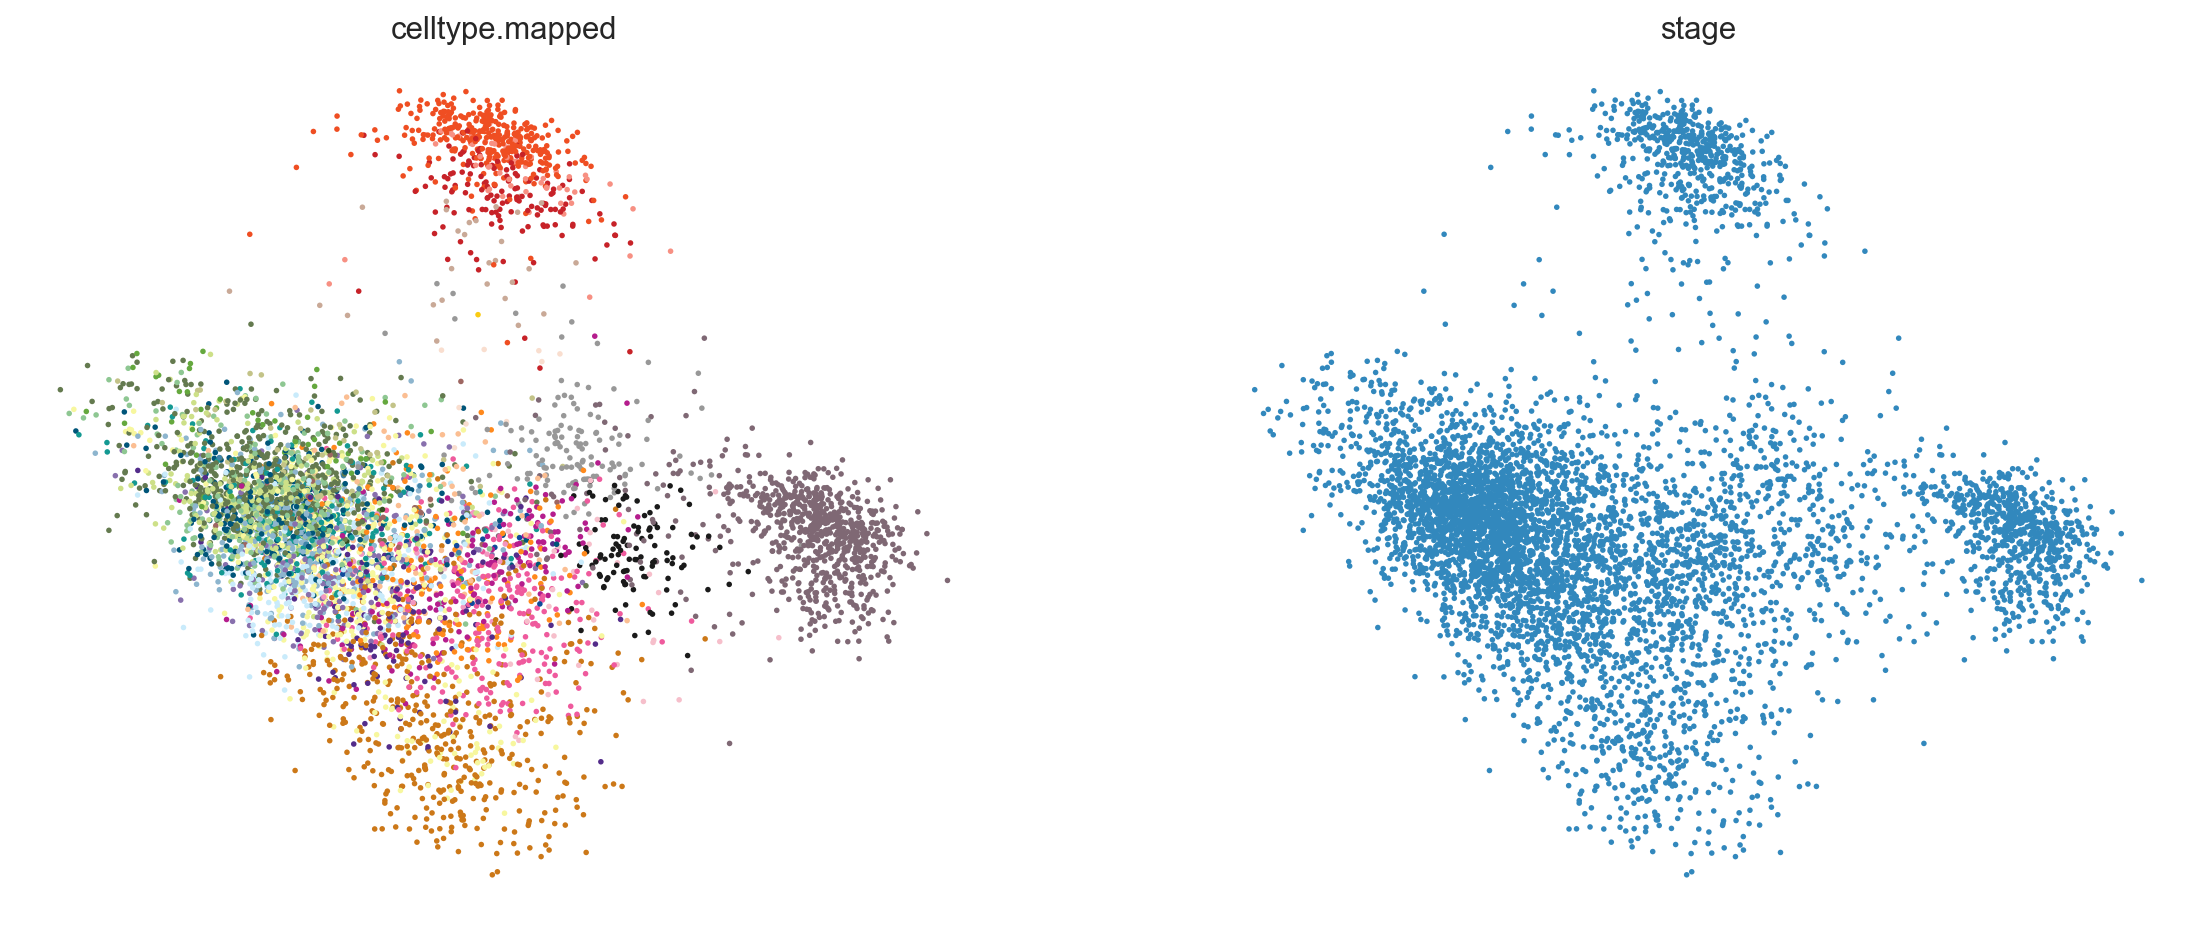

In [37]:
sc.pl.pca(adata, components=[1,2], color=["celltype.mapped","stage"], size=25, legend_loc=None)

Load precomputed PCA coordinates

In [38]:
io["pca_rna"] = io["basedir"] + "/results/rna/dimensionality_reduction/all_cells/E7.5_rep1-E7.5_rep2-E8.0_rep1-E8.0_rep2-E8.5_rep1-E8.5_rep2_pca_features2500_pcs30_batchcorrectionbysample.txt.gz"
pca_mtx = pd.read_csv(io["pca_rna"]).set_index("cell", drop=True).loc[adata.obs.index].to_numpy()
adata.obsm["X_pca"] = pca_mtx

## Batch effect correction


In [39]:
# sc.external.pp.harmony_integrate(adata, key="stage", basis='X_pca', adjusted_basis='X_pca_harmony')

## Neighbourhood graph

In [40]:
# sc.pp.neighbors(adata, use_rep="X_pca_harmony", n_neighbors=15)
sc.pp.neighbors(adata, use_rep="X_pca", n_neighbors=25)

## UMAP

Load precomputed UMAP coordinates


In [41]:
io["umap_rna"] = io["basedir"] + "/results/rna/dimensionality_reduction/all_cells/E7.5_rep1-E7.5_rep2-E8.0_rep1-E8.0_rep2-E8.5_rep1-E8.5_rep2_umap_features2500_pcs30_neigh25_dist0.3.txt.gz"
umap_mtx = pd.read_csv(io["umap_rna"]).set_index("cell", drop=True).loc[adata.obs.index].to_numpy()
adata.obsm["X_umap"] = umap_mtx

Run UMAP


In [42]:
# sc.tl.umap(adata, min_dist=0.5, n_components=2)

Plot UMAP


... storing 'Metacell' as categorical


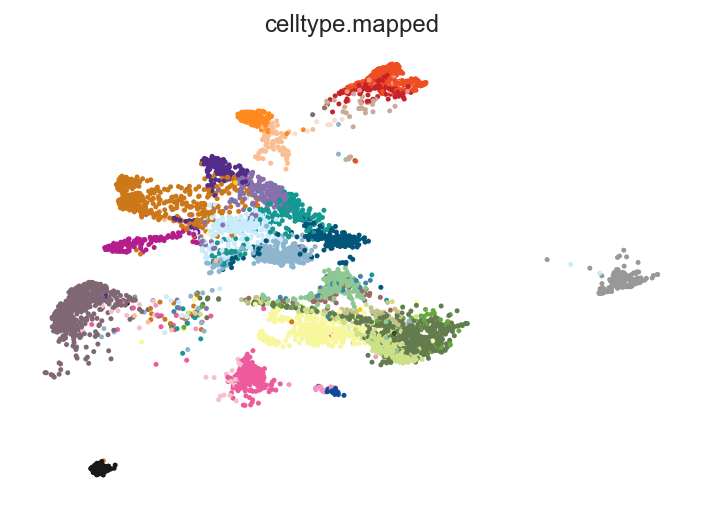

In [57]:
sc.pl.umap(adata, color=["celltype.mapped"], size=25, legend_loc=None)


# Metacell

In [44]:
from metacells.core import Metacells
from metacells import plot

## Build input graph

In [45]:
# kernel_model = metacells.build_graph.MetacellGraph(adata, build_on='X_pca', verbose=True)
# K is a sparse matrix representing input to metacell alg
# K = kernel_model.rbf()

# Find metacells

Fast kernel archetypal analysis. Finds archetypes and weights given annotated data matrix. Modifies annotated data matrix in place to include Metacell assignments in ad.obs['Metacell']

In [46]:
opts["n_waypoint_eigs"] = 10 # Number of eigenvalues to consider when initializing metacells
opts["N_METACELLS"] = 1000  # number of metacells

In [47]:
graph_model = Metacells(adata, build_kernel_on="X_pca", n_metacells=opts["N_METACELLS"], verbose=True)

In [49]:
graph_model.fit(n_iter=5)

Building kernel...
Computing kNN graph using scanpy NN ...
Computing radius for adaptive bandwidth kernel...



Making graph symmetric...
Computing RBF kernel...



Building similarity LIL matrix...



Constructing CSR matrix...
Computing diffusion components from X_pca for waypoint initialization ... 
Determing nearest neighbor graph...
Done.
Sampling waypoints ...
Done.
Initializing residual matrix using greedy column selection
Initializing f and g...



Selecting 816 cells from waypoint initialization.
Selecting 184 cells from greedy initialization.
Starting iteration 1.
Completed iteration 1.
Starting iteration 10.
Completed iteration 10.
Converged after 10 iterations.


Save cell2metacell assignments

In [148]:
to_save = adata.obs.loc[:,['Metacell',"cell"]]
to_save.to_csv(io["txt_outfile"], sep="\t", header=True, index=False)


In [136]:
adata.obs.loc(:,"Metacell")


SyntaxError: invalid syntax (<ipython-input-136-8681a3cd4636>, line 1)

Load precomputed PCA coordinates

In [43]:
io["pca_rna"] = io["basedir"] + "/results/rna/dimensionality_reduction/all_cells/E7.5_rep1-E7.5_rep2-E8.0_rep1-E8.0_rep2-E8.5_rep1-E8.5_rep2_pca_features2500_pcs30_batchcorrectionbysample.txt.gz"
pca_mtx = pd.read_csv(io["pca_rna"]).set_index("cell", drop=True).loc[adata.obs.index].to_numpy()

In [53]:
model = graph_model

In [64]:
graph_model.get_assignments().head()


,Metacell
index,
E8.5_rep2#AAACAGCCAACTAGGG-1,E8.5_rep2#AAACAGCCAACTAGGG-1
E8.5_rep2#AAACAGCCAAGCTAAA-1,E8.5_rep2#GGTTACTAGCTGAGGG-1
E8.5_rep2#AAACAGCCACCGTTCC-1,E8.5_rep2#GGACTAAAGTCACTCC-1
E8.5_rep2#AAACAGCCACTTAACG-1,E8.5_rep2#TGAAGGATCACGTTAA-1
E8.5_rep2#AAACATGCAAGGTCCT-1,E8.5_rep2#AAACATGCAAGGTCCT-1


## Plot model convergence



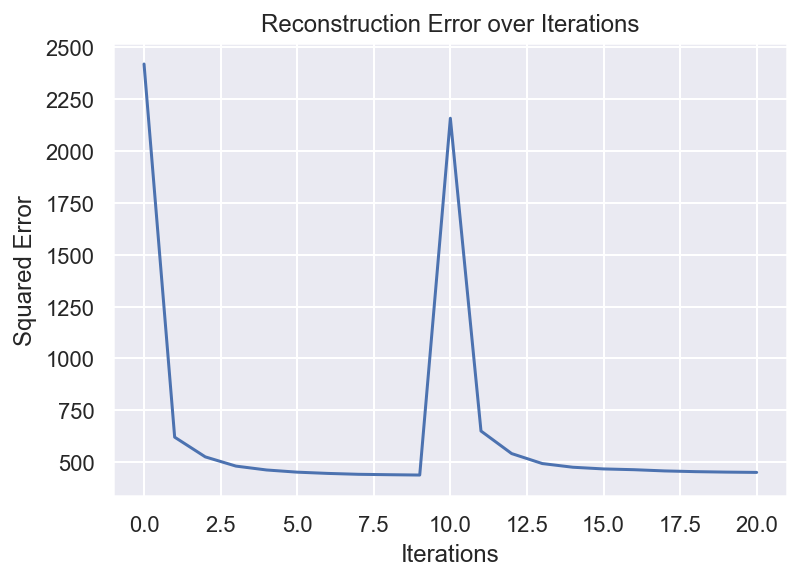

In [65]:
%matplotlib inline
graph_model.plot_convergence()


### Show locations of centers on UMAP


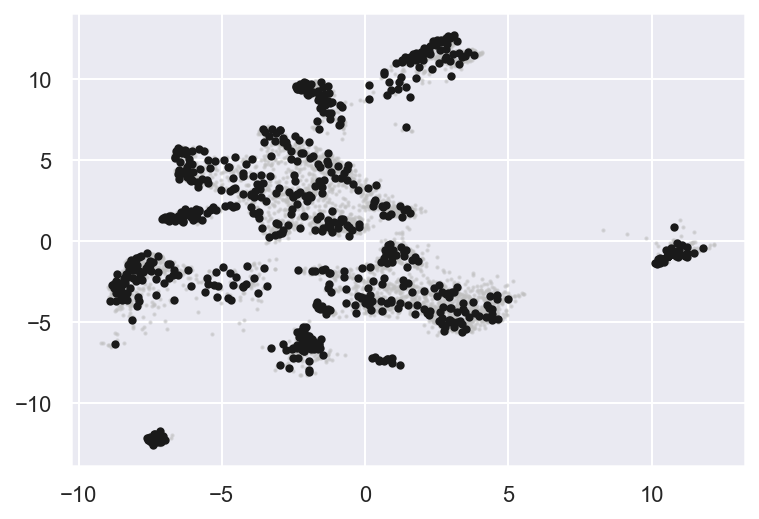

In [71]:
# cx = graph_model.get_centers()
# Y = adata.obsm["X_umap"]
# plt.scatter(Y[:,0], Y[:,1], c="silver", alpha=0.5, marker=".", s=5.)
# plt.scatter(Y[cx,0], Y[cx,1], c="k", s=10., marker="o")

In [ ]:
ad = adata
key='X_umap'
colour_metacells=True
title='Metacell Assignments'
cmap='Set2'
figsize=(5,5)

umap = pd.DataFrame(adata.obsm[key]).set_index(ad.obs_names).join(ad.obs['Metacell'])
mcs = umap.loc[ad.obs['Metacell'].unique()]

plt.figure()
sns.scatterplot(x=umap[0], y=umap[1], hue=umap["Metacell"])


# sns.scatterplot(x=0, y=1, hue='Metacell', data=umap, s=5, cmap=cmap, legend=None)

# sns.scatterplot(x=0, y=1, s=20, hue='Metacell', data=mcs, cmap=cmap, edgecolor='black', linewidth=1.25, legend=None)

plt.xlabel(f'{key}-0')
plt.ylabel(f'{key}-1')
plt.title(title)
ax = plt.gca()
ax.set_axis_off()
plt.show()
# plt.close()


In [96]:
plot.plot_2D(adata, key='X_umap', colour_metacells=False)

TypeError: object of type 'int' has no len()

<Figure size 360x360 with 0 Axes>

### Plot distribution of metacell sizes




/Users/ricard/anaconda3/envs/base_new/lib/python3.6/site-packages/seaborn/distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


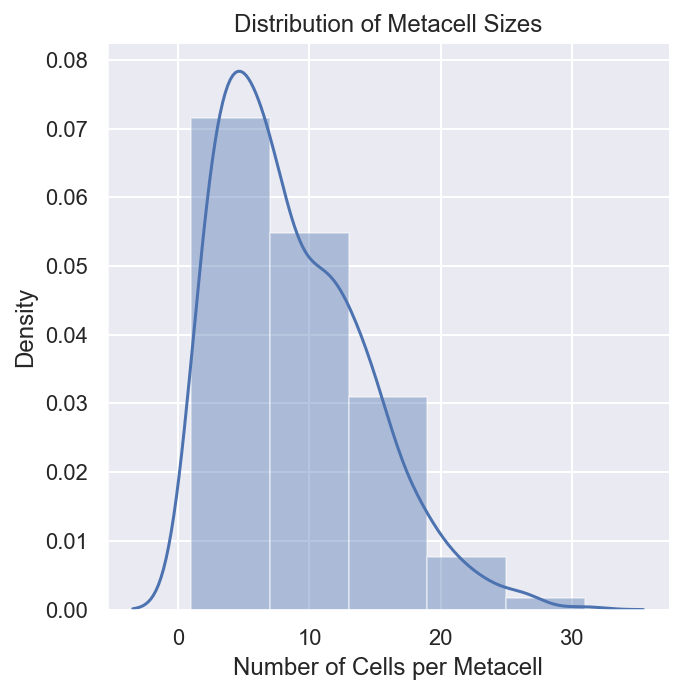

Metacell
E8.5_rep2#AAACAGCCAACTAGGG-1     1
E8.5_rep2#AAACATGCAAGGTCCT-1     8
E8.5_rep2#AAACCAACAGTCTAAT-1    11
E8.5_rep2#AAACCGCGTGGTTCCC-1     7
E8.5_rep2#AAACCGGCAGCATGTC-1     2
                                ..
E8.5_rep2#TTTGGCTGTTGTTCAC-1    10
E8.5_rep2#TTTGGTAAGCAACAAG-1     6
E8.5_rep2#TTTGGTGCACGCAACT-1    12
E8.5_rep2#TTTGTCCCACAGACTC-1     4
E8.5_rep2#TTTGTCCCATCCATCT-1     2
Name: index, Length: 696, dtype: int64

In [98]:
plot.plot_metacell_sizes(ad, bins=5)

/Users/ricard/anaconda3/envs/base_new/lib/python3.6/site-packages/seaborn/distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:ylabel='Density'>

Text(0.5, 1.0, 'Hard cluster size')

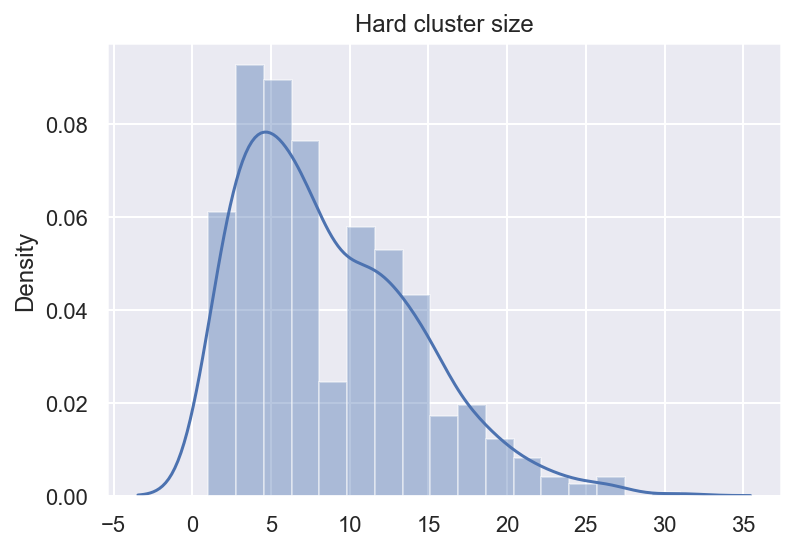

In [101]:
from collections import Counter

# metacell_sizes = graph_model.get_sizes()
metacell_sizes = Counter(np.argmax(graph_model.A_, axis=0))
sns.distplot([_ for _ in metacell_sizes.values()])

plt.title("Hard cluster size")


# Make sure cell types are all represented

In [103]:
# get labels of model centers
archetype_labels = adata[cx].obs["celltype.mapped"].values


# get counts for labels for archetypes
archetype_label_counts = Counter(archetype_labels)

# get counts for all cells
all_label_counts = Counter(adata.obs["celltype.mapped"].values)

# unzip
labels, lcounts = zip(*archetype_label_counts.items())
all_labels, all_lcounts = zip(*all_label_counts.items())

# normalize
lcounts = lcounts / np.sum(lcounts)
all_lcounts = all_lcounts / np.sum(all_lcounts)

# dset
lcounts_dset = np.concatenate([np.array(["archetypes"] * len(lcounts)), 
                       np.array(["all"] * len(all_lcounts))])

# make into dataframe
label_df = pd.DataFrame({"labels": np.concatenate([labels, all_labels]),
           "counts": np.concatenate([lcounts, all_lcounts]),
           "data": lcounts_dset})

<AxesSubplot:xlabel='labels', ylabel='counts'>

Text(0.5, 1.0, 'Frequency by PhenoGraph cluster')

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]),
 [Text(0, 0, 'Intermediate_mesoderm'),
  Text(1, 0, 'ExE_endoderm'),
  Text(2, 0, 'Gut'),
  Text(3, 0, 'Spinal_cord'),
  Text(4, 0, 'Cardiomyocytes'),
  Text(5, 0, 'Surface_ectoderm'),
  Text(6, 0, 'Pharyngeal_mesoderm'),
  Text(7, 0, 'ExE_mesoderm'),
  Text(8, 0, 'Somitic_mesoderm'),
  Text(9, 0, 'Mesenchyme'),
  Text(10, 0, 'ExE_ectoderm'),
  Text(11, 0, 'Erythroid3'),
  Text(12, 0, 'Caudal_Mesoderm'),
  Text(13, 0, 'Endothelium'),
  Text(14, 0, 'Erythroid2'),
  Text(15, 0, 'Paraxial_mesoderm'),
  Text(16, 0, 'Forebrain_Midbrain_Hindbrain'),
  Text(17, 0, 'Parietal_endoderm'),
  Text(18, 0, 'Haematoendothelial_progenitors'),
  Text(19, 0, 'Erythroid1'),
  Text(20, 0, 'Blood_progenitors_2'),
  Text(21, 0, 'NMP'),
  Text(22, 0, 'Visceral_endoderm'),
  Text(23, 0, 'Notochord'),
  Text(24, 0, 'Allantois'),
  Text(25, 0, 'Def._endoderm'),
  Text

Text(0.5, 1.0, 'Frequency by cell type')

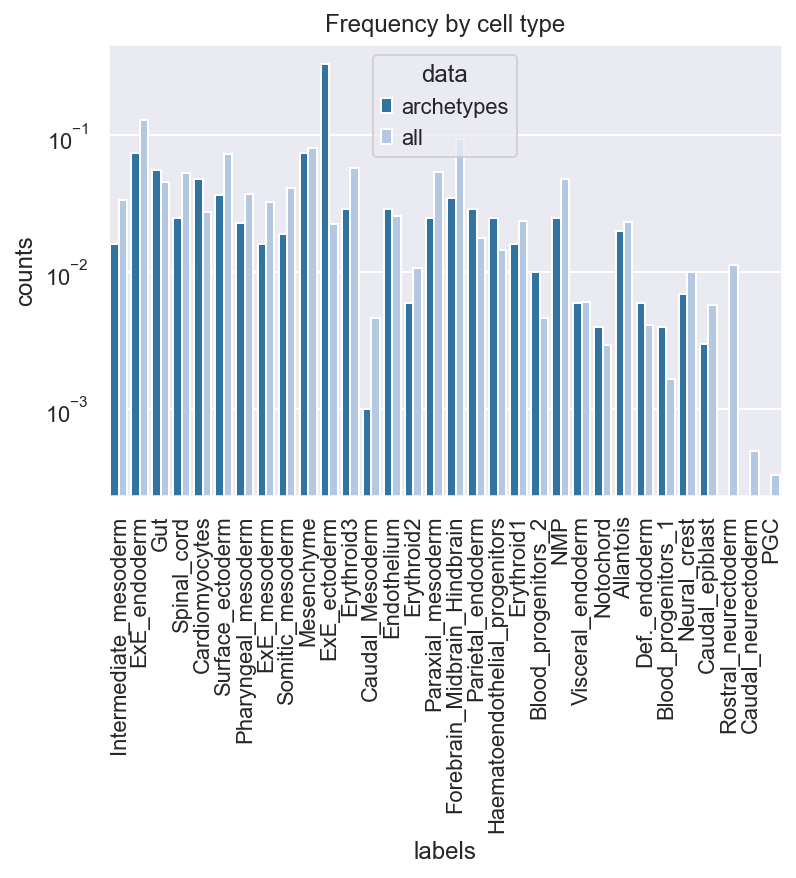

In [104]:
sns.barplot(x="labels", y="counts", hue="data", data=label_df, palette="tab20")
plt.title("Frequency by PhenoGraph cluster")
plt.xticks(rotation=90)
plt.yscale("log")
plt.title("Frequency by cell type")

# Get metacell coordinates and make metacell AnnData


In [ ]:
# metacell_celltypes = adata.obs["celltype.mapped"].values[cx]

# get coordinates
# coords = graph_model.get_coordinates(adata.obsm["raw_counts"])
# coords = graph_model.get_coordinates(adata.X)

#A @ adata.obsm["raw_counts"]
#model.get_coordinates(adata.obsm["raw_counts"])

# create AnnData
# metacell_adata = sc.AnnData(coords)

#.var
# metacell_adata.var = adata.var

# .obs
# metacell_adata.obs_names = adata.obs_names[cx]
# metacell_adata.obs["celltype.mapped"] = metacell_celltypes
# metacell_adata.obs["size"] = metacell_sizes
# metacell_adata

# .uns
# metacell_adata.uns["celltype.mapped_colors"] = adata.uns["celltype.mapped_colors"]

In [114]:
# adata.raw = adata
metacell_adata = model.summarize_by_metacell(aggregate_by='sum')

metacell_adata

Summing features for each metacell.


/Users/ricard/anaconda3/envs/base_new/lib/python3.6/site-packages/anndata/_core/anndata.py:119: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 696 × 32245
    obs: 'cell', 'sample', 'barcode', 'stage', 'nFeature_RNA', 'nCount_RNA', 'mitochondrial_percent_RNA', 'ribosomal_percent_RNA', 'pass_rnaQC', 'celltype.mapped', 'celltype.score', 'closest.cell', 'hybrid_score', 'doublet_call', 'TSSEnrichment_atac', 'ReadsInTSS_atac', 'PromoterRatio_atac', 'NucleosomeRatio_atac', 'nFrags_atac', 'BlacklistRatio_atac', 'pass_atacQC', 'celltype.predicted', 'Metacell', 'Metacell_Entropy'

In [117]:
metacell_adata


AnnData object with n_obs × n_vars = 696 × 32245
    obs: 'cell', 'sample', 'barcode', 'stage', 'nFeature_RNA', 'nCount_RNA', 'mitochondrial_percent_RNA', 'ribosomal_percent_RNA', 'pass_rnaQC', 'celltype.mapped', 'celltype.score', 'closest.cell', 'hybrid_score', 'doublet_call', 'TSSEnrichment_atac', 'ReadsInTSS_atac', 'PromoterRatio_atac', 'NucleosomeRatio_atac', 'nFrags_atac', 'BlacklistRatio_atac', 'pass_atacQC', 'celltype.predicted', 'Metacell', 'Metacell_Entropy'

In [123]:
metacell_adata.obs.head(n=2)

,cell,sample,barcode,stage,nFeature_RNA,nCount_RNA,mitochondrial_percent_RNA,ribosomal_percent_RNA,pass_rnaQC,celltype.mapped,...,ReadsInTSS_atac,PromoterRatio_atac,NucleosomeRatio_atac,nFrags_atac,BlacklistRatio_atac,pass_atacQC,celltype.predicted,Metacell,Metacell_Entropy,n_counts
Metacell,,,,,,,,,,,,,,,,,,,,,
E8.5_rep2#AAACAGCCAACTAGGG-1,E8.5_rep2#AAACAGCCAACTAGGG-1,E8.5_rep2,AAACAGCCAACTAGGG-1,E8.5,4881.0,16945.0,10.185896,15.084096,True,ExE_ectoderm,...,678.0,0.169844,1.407732,7972.0,0.017122,True,ExE_ectoderm,E8.5_rep2#AAACAGCCAACTAGGG-1,0.011697,4708.327148
E8.5_rep2#AAACATGCAAGGTCCT-1,E8.5_rep2#AAACATGCAAGGTCCT-1,E8.5_rep2,AAACATGCAAGGTCCT-1,E8.5,5657.0,17607.0,3.776907,9.246322,True,ExE_mesoderm,...,5136.0,0.166001,1.548734,60614.0,0.013726,True,ExE_mesoderm,E8.5_rep2#AAACATGCAAGGTCCT-1,0.087154,40343.492188


In [128]:
metacell_adata.uns["celltype.mapped_colors"] = adata.uns["celltype.mapped_colors"]
metacell_adata.uns["stage_colors"] = adata.uns["stage_colors"]

## Normalise 

In [118]:
# store raw counts
# metacell_adata.obsm["raw_counts"] = metacell_adata.X.copy()

# normalize and visualize
sc.pp.normalize_per_cell(metacell_adata)
sc.pp.log1p(metacell_adata)

## Visualise

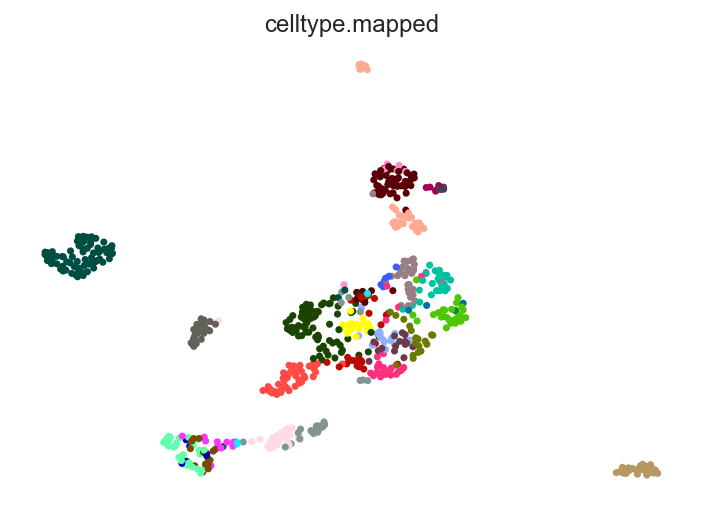

In [122]:
sc.tl.pca(metacell_adata)
sc.pp.neighbors(metacell_adata, n_neighbors=10)
sc.tl.umap(metacell_adata, min_dist=0.5)


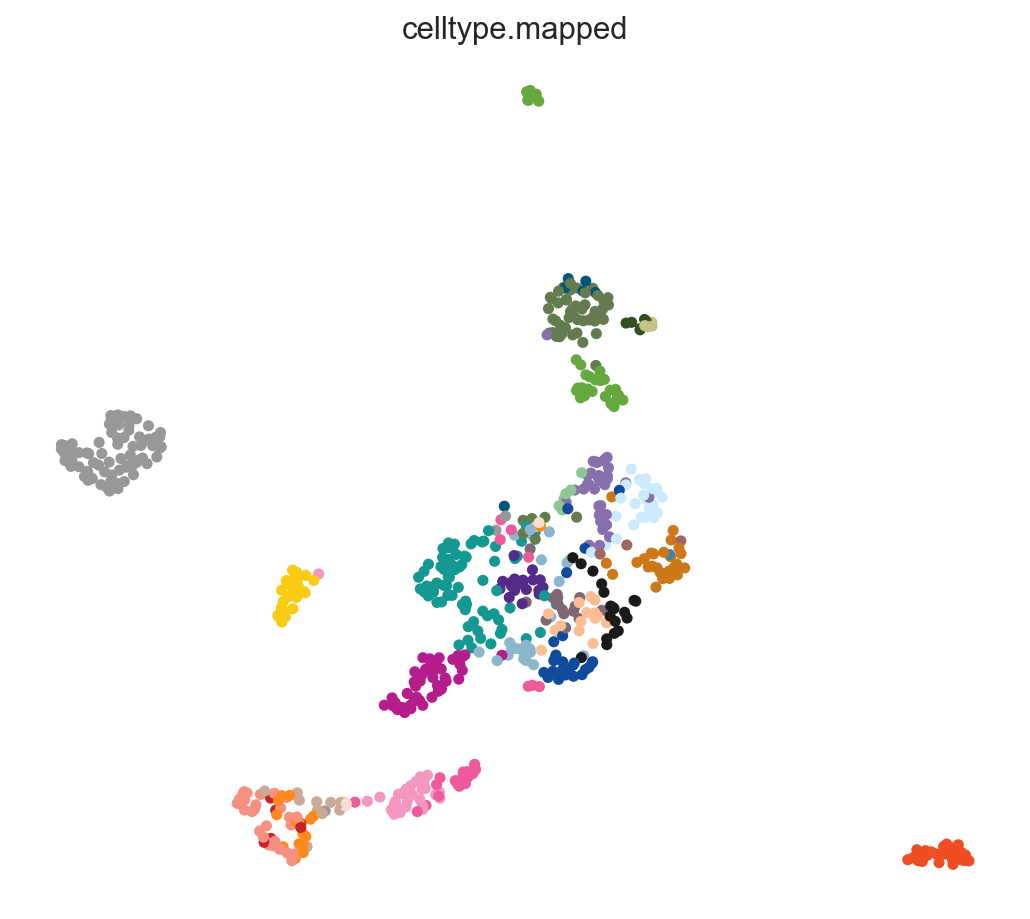

In [132]:
sc.pl.umap(metacell_adata, color=["celltype.mapped"], size=100, legend_loc=None)




# Save anndata object

In [ ]:
metacell_adata.write_h5ad(io["anndata_outfile"])